# Mutual Fund Analytics Platform - Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the Bluestock Mutual Fund Analytics datasets.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Optional style
plt.style.use("ggplot")

# Load datasets
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")

print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Transactions:", transactions.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Transactions: (32778, 13)


In [2]:
# Display first 5 rows
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [5]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [6]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [7]:
print("Fund Master")
print(fund_master.isnull().sum())

print("\nNAV")
print(nav.isnull().sum())

print("\nAUM")
print(aum.isnull().sum())

print("\nSIP")
print(sip.isnull().sum())

print("\nTransactions")
print(transactions.isnull().sum())

Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

NAV
amfi_code    0
date         0
nav          0
dtype: int64

AUM
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

SIP
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

Transactions
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group         

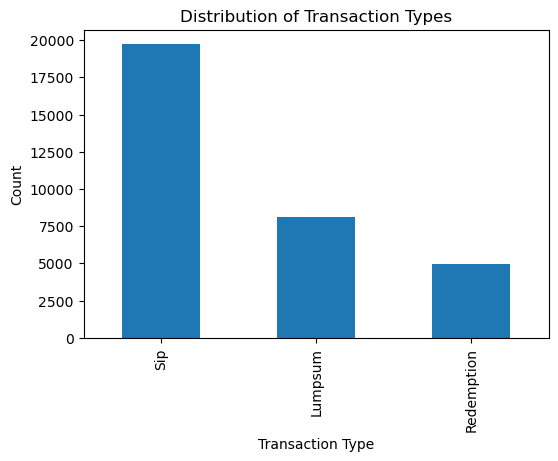

In [8]:
import matplotlib.pyplot as plt

transactions["transaction_type"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

## NAV Trend Analysis

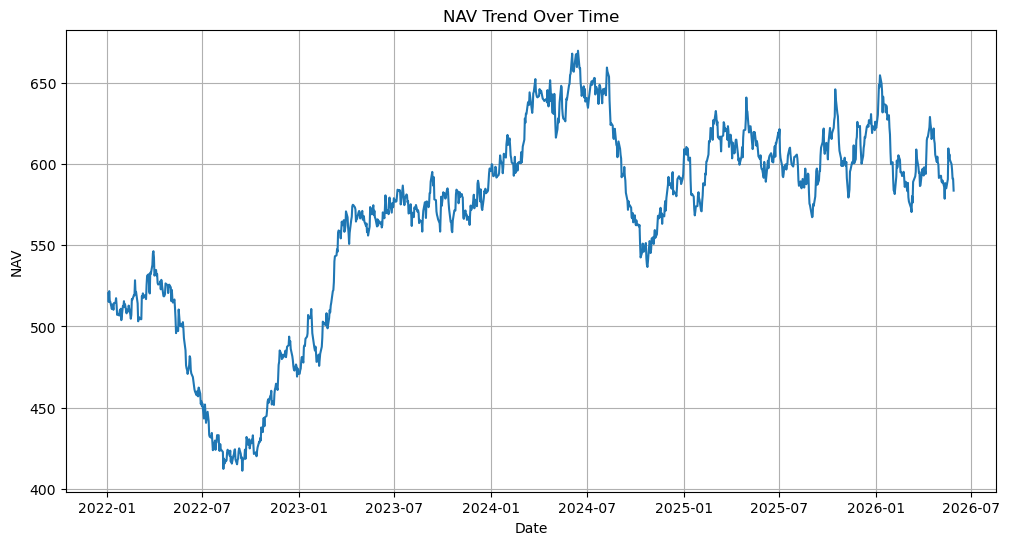

In [9]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Select one fund (example: first AMFI code)
sample_fund = nav[nav["amfi_code"] == nav["amfi_code"].iloc[0]]

plt.figure(figsize=(12,6))
plt.plot(sample_fund["date"], sample_fund["nav"])

plt.title("NAV Trend Over Time")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)

plt.show()

### Observation

- The selected fund's NAV shows a generally increasing trend over time.
- There are periodic fluctuations due to market movements.

## Assets Under Management (AUM) by Fund House

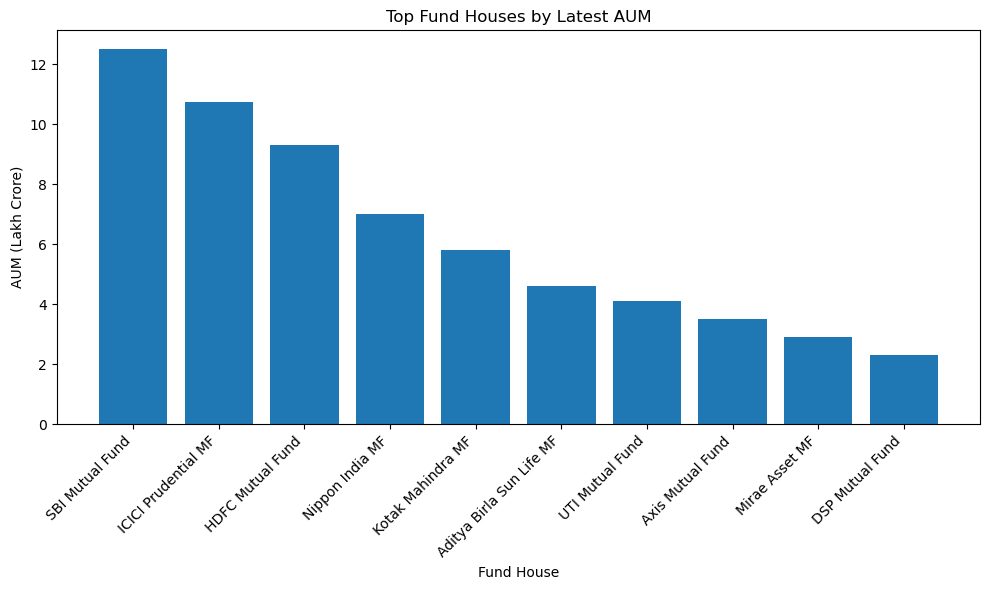

In [15]:
latest_aum = latest_aum.sort_values(
    by="aum_lakh_crore",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    latest_aum["fund_house"],
    latest_aum["aum_lakh_crore"]
)

plt.xticks(rotation=45, ha="right")

plt.title("Top Fund Houses by Latest AUM")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")

plt.tight_layout()
plt.show()

### Observation

- SBI Mutual Fund has the highest AUM among the fund houses.
- ICICI Prudential MF and HDFC Mutual Fund are the next largest AMCs.

## Monthly SIP Inflow Trend

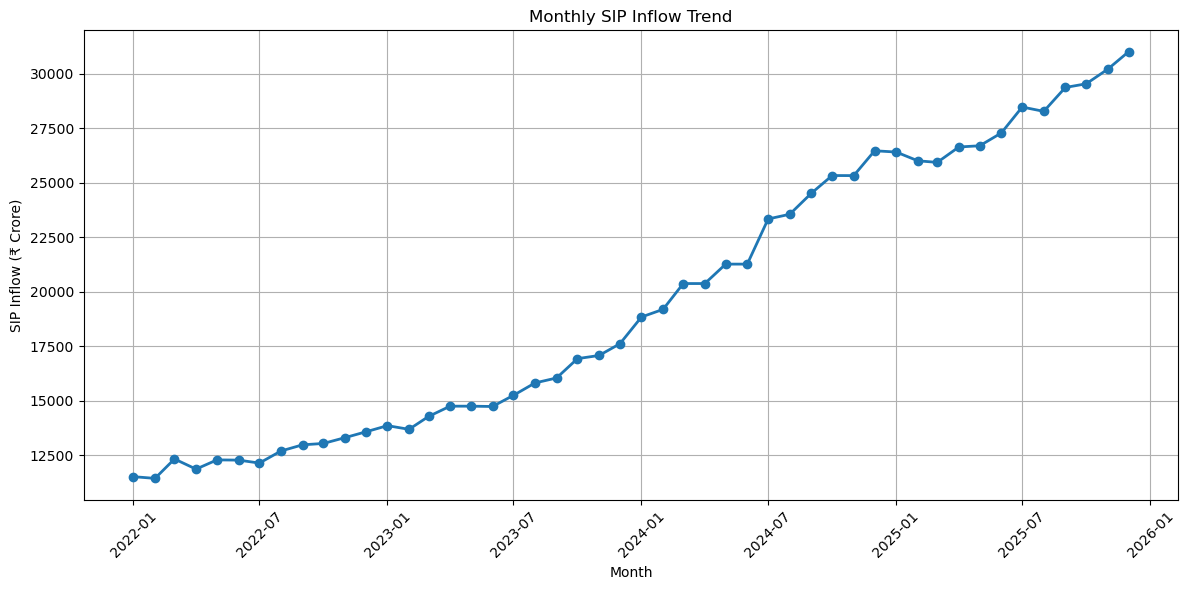

In [16]:
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

- Monthly SIP inflows show a steady upward trend over time.
- The increase indicates growing investor confidence and participation in mutual funds.

## Investor Age Group Distribution

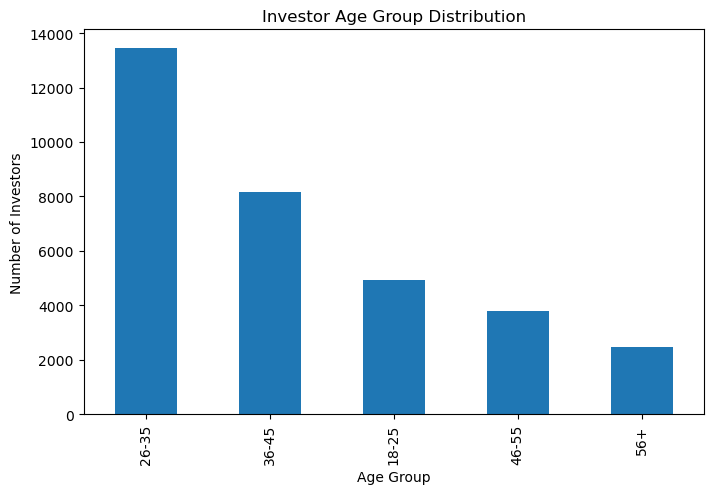

In [17]:
plt.figure(figsize=(8,5))

transactions["age_group"].value_counts().plot(
    kind="bar"
)

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.show()

### Observation

- The majority of investors belong to the working-age population.
- Investors aged 26–35 and 36–45 contribute significantly to mutual fund investments.

## Gender Distribution of Investors

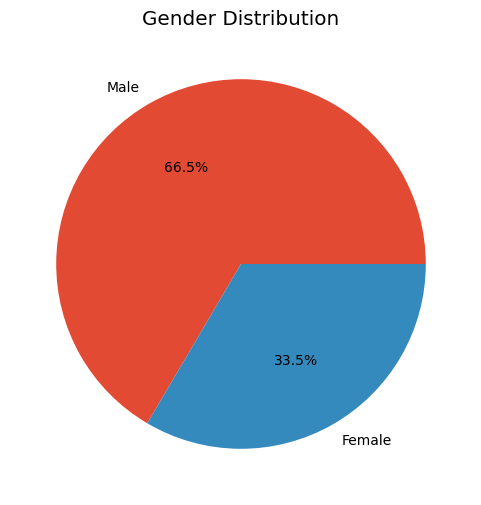

In [25]:
plt.figure(figsize=(6,6))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.show()

## Top 10 States by Investment Amount

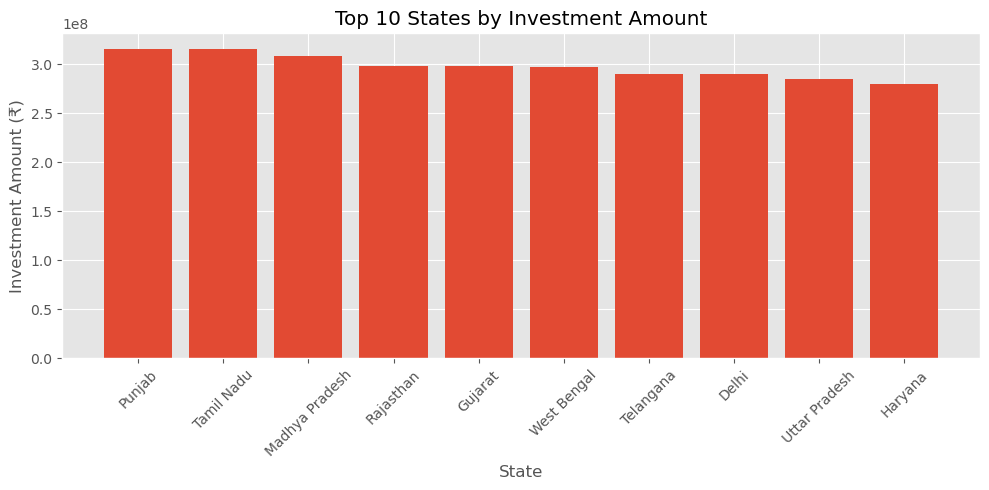

In [26]:
state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(state_amount.index, state_amount.values)

plt.xticks(rotation=45)

plt.title("Top 10 States by Investment Amount")
plt.xlabel("State")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.show()

## Transaction Type Distribution

plt.figure(figsize=(7,7))

transactions["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")
plt.ylabel("")

plt.show()

### Observation

- SIP transactions form the largest share of investor activity.
- Lumpsum and Redemption transactions occur less frequently.

In [29]:
import seaborn as sns

## Category-wise Net Inflow Heatmap

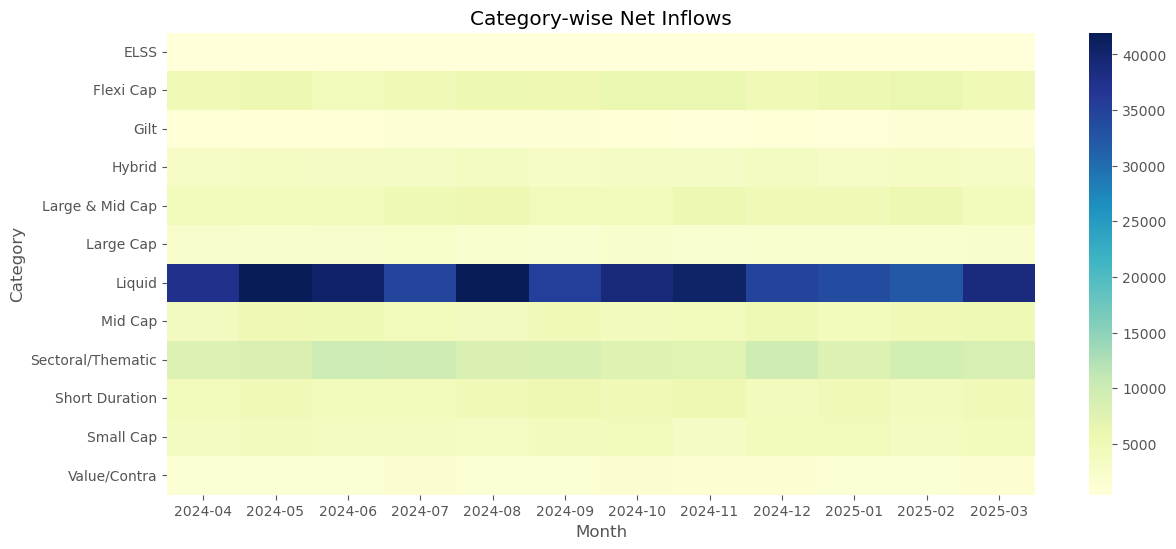

In [30]:
# Load category inflow dataset
category = pd.read_csv("../data/raw/05_category_inflows.csv")

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")

plt.title("Category-wise Net Inflows")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

### Observation

- Some categories consistently attract higher inflows than others.
- The heatmap highlights trends across different months.

## Industry Folio Growth

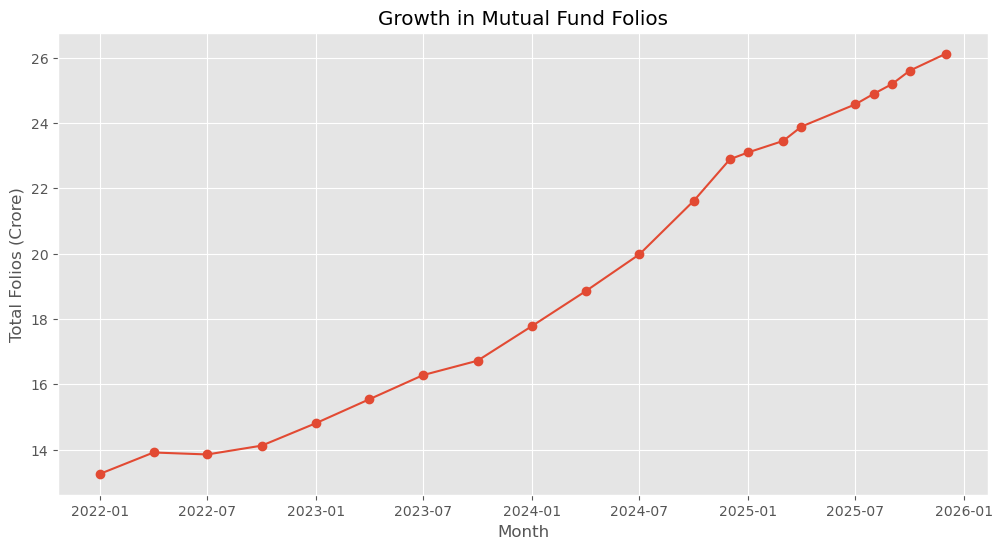

In [31]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Growth in Mutual Fund Folios")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

### Observation

- The total number of mutual fund folios has increased steadily over time.
- This indicates growing investor participation in the mutual fund industry.

## Sector Allocation in Portfolio Holdings

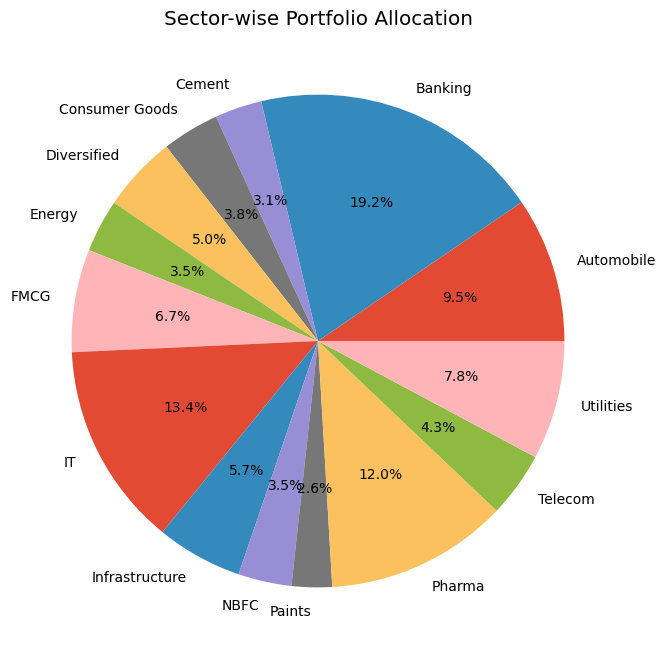

In [33]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

sector_weights = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

plt.title("Sector-wise Portfolio Allocation")

plt.show()

### Observation

- Banking, IT, Pharma and other sectors occupy different proportions of portfolio allocation.
- This helps understand sector diversification across holdings.

## Top 10 Funds by 1-Year Return

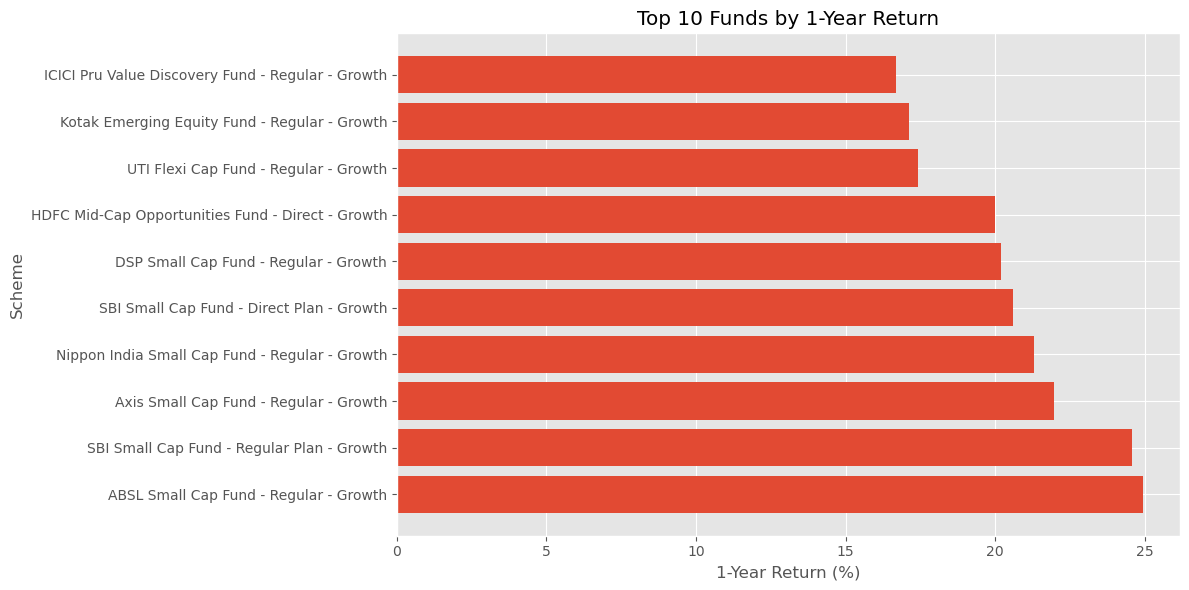

In [34]:
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

top10 = performance.sort_values(
    by="return_1yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["return_1yr_pct"]
)

plt.title("Top 10 Funds by 1-Year Return")
plt.xlabel("1-Year Return (%)")
plt.ylabel("Scheme")

plt.tight_layout()
plt.show()

### Observation

- These funds delivered the highest 1-year returns among all schemes.
- They may be attractive to growth-oriented investors.

## Risk Grade Distribution

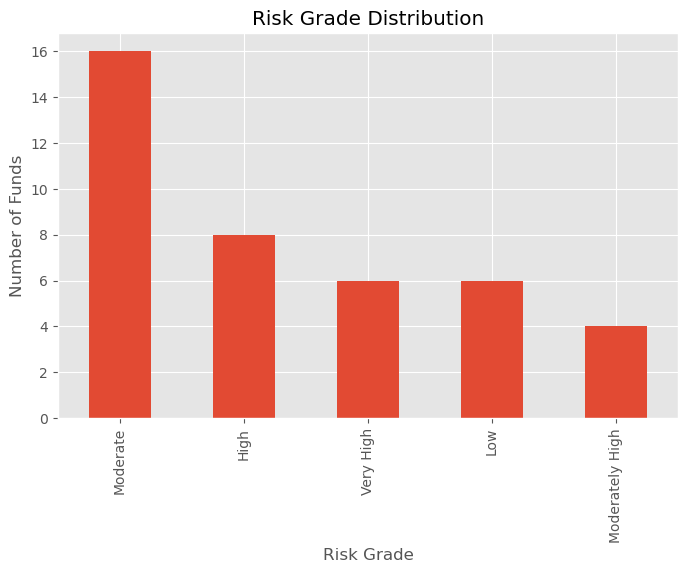

In [35]:
plt.figure(figsize=(8,5))

performance["risk_grade"].value_counts().plot(
    kind="bar"
)

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Funds")

plt.show()

### Observation

- Most schemes fall under Moderate or Very High risk categories.
- Investors should consider risk appetite before investing.

## Expense Ratio Distribution

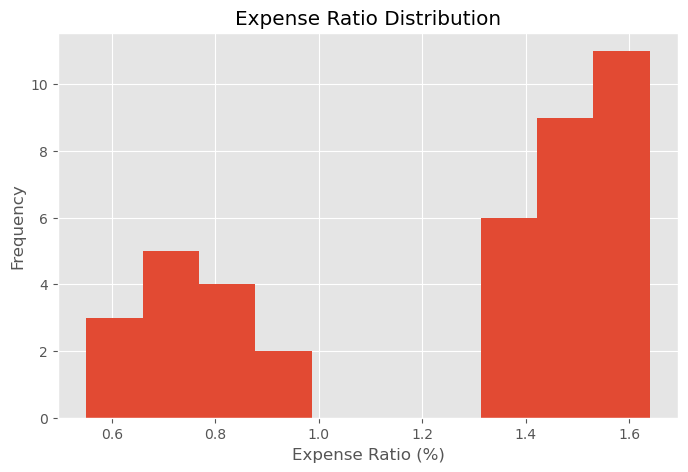

In [36]:
plt.figure(figsize=(8,5))

plt.hist(
    performance["expense_ratio_pct"],
    bins=10
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most funds have expense ratios clustered within a limited range.
- Lower expense ratios may improve long-term investor returns.

## Morningstar Rating Distribution

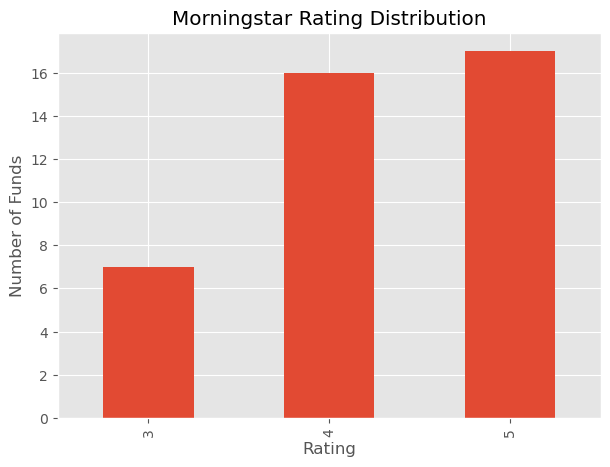

In [39]:
plt.figure(figsize=(7,5))

performance["morningstar_rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Morningstar Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.show()

### Observation

- The distribution shows how funds are rated .
- Higher-rated funds generally indicate stronger historical performance.

# Key EDA Findings

1. NAV values generally show an upward trend with periodic market fluctuations.
2. SBI Mutual Fund has the highest Assets Under Management (AUM) among the analyzed fund houses.
3. Monthly SIP inflows have increased steadily, indicating growing investor participation.
4. SIP transactions account for the largest proportion of all transactions.
5. Most investors belong to the working-age population.
6. Investment amounts vary significantly across different states.
7. Mutual fund folio counts have shown continuous growth over time.
8. Portfolio holdings are diversified across multiple sectors.
9. Some schemes significantly outperform others based on 1-year returns.
10. Expense ratios and risk grades vary across schemes, highlighting the need for careful fund selection.